# Industrial Sensor Monitoring: A Simulated Anomaly Investigation

Can machine-specific sensor baselines distinguish isolated extreme readings from changes that persist over time? This notebook demonstrates that workflow for temperature and vibration. The readings are simulated, so the results validate an analysis process—not the condition or failure risk of real equipment.

## 1. Problem and analytical question

Industrial monitoring needs to separate normal variation from sensor behavior that warrants investigation. Here, the question is whether six-hour rolling behavior departs from each machine's own healthy-period baseline, while also identifying unusually high individual readings. A fixed random seed makes this simulated investigation reproducible; charts and reports are written to `outputs/`.

In [ ]:
# libaries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# random seed for reproducibility.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# folder.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# visual style and palette.
BLUE = "#2878B5"
RED = "#D62728"
DARK = "#17212B"
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15

print("Output folder:", OUTPUT_DIR.resolve())

Output folder: C:\Users\HP\Desktop\vgy\outputs


## 2. Data

Each observation is one machine's temperature (°C) and vibration (mm/s) reading at a timestamp. The generated sample covers 30 days from 1 January 2025 at ten-minute intervals for the Reactor, Transfer Pump, and Heat Exchanger. It includes daily cycles and random variation; the simulation deliberately adds gradual rises to both sensors on the Transfer Pump and Heat Exchanger, plus a small number of paired sensor spikes. Missing values and duplicate rows are also introduced to test data-quality handling.

In [326]:
# Create timestamps and the three machine names.
timestamps = pd.date_range("2025-01-01", periods=30 * 24 * 6, freq="10min")
machine_names = ["Reactor", "Transfer Pump","Heat Exchanger"]
time_number = np.arange(len(timestamps))
hour_of_day = timestamps.hour.to_numpy() + timestamps.minute.to_numpy() / 60
daily_cycle = np.sin(2 * np.pi * (hour_of_day - 6) / 24)
sensor_frames = []

# Generate sensor readings for each machine.
for machine_name in machine_names:
    machine_number = machine_names.index(machine_name)
    temperature_base = 62 + machine_number * 2
    vibration_base = 2.4 + machine_number * 0.25
    temperature = temperature_base + 3.5 * daily_cycle
    temperature = temperature + np.random.normal(0, 0.8, len(timestamps))
    vibration = vibration_base + 0.45 * daily_cycle
    vibration = vibration + np.random.normal(0, 0.18, len(timestamps))

    # Add gradual temperature and vibration drifts to two machines.
    if machine_name == "Transfer Pump":
        drift = np.maximum(time_number - 10 * 24 * 6, 0) / (20 * 24 * 6)
        temperature = temperature + 13 * drift
        vibration = vibration + 2.4 * drift
    elif machine_name == "Heat Exchanger":
        drift = np.maximum(time_number - 14 * 24 * 6, 0) / (16 * 24 * 6)
        temperature = temperature + 10 * drift
        vibration = vibration + 2.0 * drift

    # Add a few sudden sensor spikes to each machine.
    spike_positions = np.random.choice(len(timestamps), size=5, replace=False)
    temperature[spike_positions] = temperature[spike_positions] + 18
    vibration[spike_positions] = vibration[spike_positions] + 5

    machine_frame = pd.DataFrame({
        "timestamp": timestamps,
        "machine_id": machine_name,
        "temperature": temperature,
        "vibration": vibration
    })
    sensor_frames.append(machine_frame)

# Combine the machine readings into one raw data table.
raw_data = pd.concat(sensor_frames, ignore_index=True)

# Set about three percent of values to missing in every column.
data_columns = ["timestamp", "machine_id", "temperature", "vibration"]
missing_count_per_column = int(len(raw_data) * 0.03)
for column_name in data_columns:
    missing_rows = np.random.choice(raw_data.index, size=missing_count_per_column, replace=False)
    raw_data.loc[missing_rows, column_name] = np.nan

# Add about one percent duplicate rows and save the raw data.
duplicate_count = int(len(raw_data) * 0.01)
duplicate_rows = raw_data.sample(n=duplicate_count, random_state=RANDOM_SEED)
raw_data = pd.concat([raw_data, duplicate_rows], ignore_index=True)
raw_data.to_csv(OUTPUT_DIR / "sensor_readings_raw.csv", index=False)

print("Raw rows:", len(raw_data))
print("Raw data saved to outputs/sensor_readings_raw.csv")

Raw rows: 13089
Raw data saved to outputs/sensor_readings_raw.csv


### Loading the generated records

The analysis reloads the saved CSV so later steps use the same artifact that can be shared or audited, rather than depending on the generator's in-memory table. The preview confirms the four fields; timestamps are still strings at this stage and are converted during cleaning.

In [327]:
# Load the raw readings and inspect a few rows.
loaded_data = pd.read_csv(OUTPUT_DIR / "sensor_readings_raw.csv")
display(loaded_data.head())
print("Shape:", loaded_data.shape)
print("Data types before cleaning:")
display(loaded_data.dtypes.to_frame(name="data_type"))

,timestamp,machine_id,temperature,vibration
0,2025-01-01 00:00:00,Reactor,58.897371,1.946423
1,2025-01-01 00:10:00,Reactor,58.392720,1.931121
2,2025-01-01 00:20:00,Reactor,59.031469,2.171363
3,2025-01-01 00:30:00,Reactor,59.748367,1.760048
4,2025-01-01 00:40:00,Reactor,58.365850,1.819583


Shape: (13089, 4)
Data types before cleaning:


,data_type
timestamp,str
machine_id,str
temperature,float64
vibration,float64


### Initial sensor summary

Whole-sample statistics and per-machine ranges provide context before cleaning and anomaly detection. Because this summary is calculated from the raw file, its means include the simulated changes and its row counts can reflect missing keys and duplicate records; it is descriptive, not a healthy operating reference.

In [328]:
# Show temperature and vibration descriptive statistics.
display(loaded_data[["temperature", "vibration"]].describe().round(2))

# Build a slide-ready summary for each machine.
machine_summary = loaded_data.groupby("machine_id").agg(
    temperature_mean=("temperature", "mean"),
    temperature_min=("temperature", "min"),
    temperature_max=("temperature", "max"),
    vibration_mean=("vibration", "mean"),
    vibration_min=("vibration", "min"),
    vibration_max=("vibration", "max"),
    row_count=("timestamp", "size")
).reset_index()
machine_summary = machine_summary.round(2)
display(machine_summary)
machine_summary.to_csv(OUTPUT_DIR / "machine_summary.csv", index=False)

,temperature,vibration
count,12697.00,12698.00
mean,66.36,3.10
std,5.13,0.87
min,56.17,1.29
25%,62.58,2.47
50%,65.55,2.90
75%,69.64,3.62
max,94.01,10.18


,machine_id,temperature_mean,temperature_min,temperature_max,vibration_mean,vibration_min,vibration_max,row_count
0,Heat Exchanger,68.65,59.80,94.01,3.44,1.92,10.18,4213
1,Reactor,62.03,56.17,84.17,2.40,1.29,7.77,4246
2,Transfer Pump,68.37,58.72,90.41,3.46,1.59,9.43,4237


**Initial comparison:** Before cleaning, the per-machine mean temperature is 62.03 °C for the Reactor, 68.37 °C for the Transfer Pump, and 68.65 °C for the Heat Exchanger. Mean vibration is 2.40, 3.46, and 3.44 mm/s respectively. These whole-period averages combine baseline behavior with the simulated drifts, so they should not be read as evidence of equipment condition.

## 3. Data quality and cleaning

Missing timestamps or machine IDs prevent a reading from being placed in time or assigned to equipment; missing sensor values can distort rolling calculations; duplicate machine-time records can overweight a period. The next steps quantify these issues, remove rows with unusable keys, interpolate sensor gaps within each machine, and retain only one record per machine and timestamp. Interpolation estimates missing values from neighboring readings; it does not recover a measurement that was actually observed.

,missing_values
timestamp,394
machine_id,393
temperature,392
vibration,391


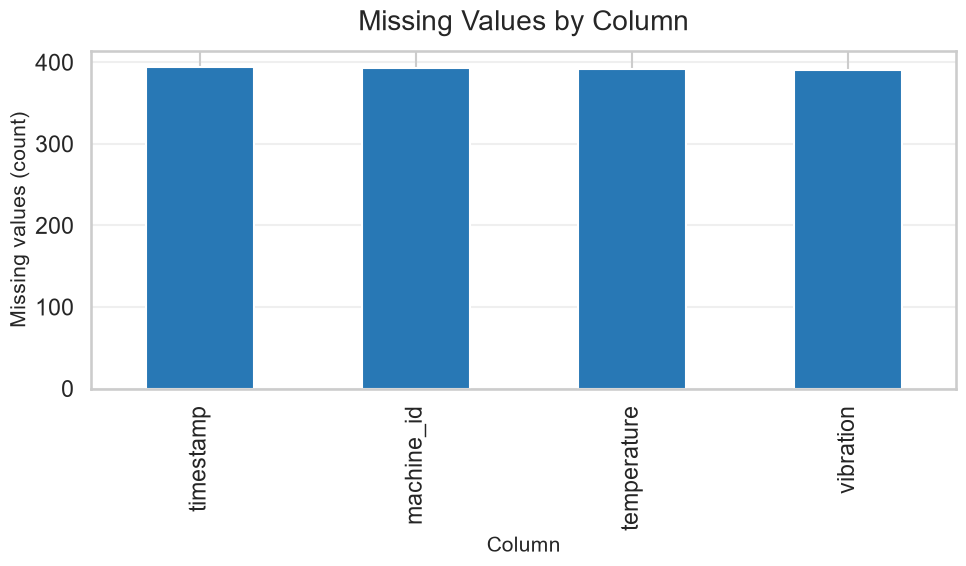

In [329]:
# Record data quality before cleaning and show the missing-value counts.
before_rows = len(loaded_data)
before_missing = int(loaded_data.isna().sum().sum())
valid_keys = loaded_data.dropna(subset=["timestamp", "machine_id"]).copy()
valid_keys["timestamp"] = pd.to_datetime(valid_keys["timestamp"], errors="coerce")
valid_keys = valid_keys.dropna(subset=["timestamp", "machine_id"])
before_duplicates = int(valid_keys.duplicated(subset=["timestamp", "machine_id"]).sum())
missing_by_column = loaded_data.isna().sum()
display(missing_by_column.rename("missing_values").to_frame())

# Chart the number of missing values in each column.
fig, ax = plt.subplots(figsize=(10, 6))
missing_by_column.plot(kind="bar", color=BLUE, ax=ax)
ax.set_title("Missing Values by Column", pad=15)
ax.set_xlabel("Column")
ax.set_ylabel("Missing values (count)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_missing_values.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Data-quality result:** The raw file has 13,089 rows, 1,570 missing field values (394 timestamps, 393 machine IDs, 392 temperatures, and 391 vibration readings), and 118 duplicate machine-time records among usable keys. Cleaning drops 775 rows without a usable timestamp or machine ID, interpolates sensor gaps, and removes duplicates. The cleaned table has 12,196 rows, zero missing values, and zero duplicate machine-time records. These are data-quality corrections—not anomaly detections or evidence of abnormal equipment behavior.

In [330]:
# Convert timestamps and remove rows without a usable time or machine ID.
clean_data = loaded_data.copy()
clean_data["timestamp"] = pd.to_datetime(clean_data["timestamp"], errors="coerce")
rows_before_key_cleanup = len(clean_data)
clean_data = clean_data.dropna(subset=["timestamp", "machine_id"])
rows_dropped_missing_keys = rows_before_key_cleanup - len(clean_data)

# Sort each machine's readings and interpolate its missing sensor values.
clean_data = clean_data.sort_values(["machine_id", "timestamp"])
sensor_columns = ["temperature", "vibration"]
for machine_name in machine_names:
    machine_mask = clean_data["machine_id"] == machine_name
    clean_data.loc[machine_mask, sensor_columns] = clean_data.loc[machine_mask, sensor_columns].interpolate(
        method="linear", limit_direction="both"
    )
clean_data = clean_data.drop_duplicates(subset=["timestamp", "machine_id"], keep="first")
clean_data = clean_data.sort_values(["timestamp", "machine_id"]).reset_index(drop=True)

# Compare quality before and after cleaning and save the table.
quality_comparison = pd.DataFrame({
    "stage": ["Before cleaning", "After cleaning"],
    "rows": [before_rows, len(clean_data)],
    "missing_values": [before_missing, int(clean_data.isna().sum().sum())],
    "duplicate_rows": [before_duplicates, int(clean_data.duplicated(subset=["timestamp", "machine_id"]).sum())],
    "rows_dropped_missing_keys": [0, rows_dropped_missing_keys]
})
display(quality_comparison)
quality_comparison.to_csv(OUTPUT_DIR / "data_quality_comparison.csv", index=False)
print("Clean data shape:", clean_data.shape)
print("Timestamp type:", clean_data["timestamp"].dtype)

,stage,rows,missing_values,duplicate_rows,rows_dropped_missing_keys
0,Before cleaning,13089,1570,118,0
1,After cleaning,12196,0,0,775


Clean data shape: (12196, 4)
Timestamp type: datetime64[us]


## 4. Exploratory analysis

Before choosing alert rules, compare all six sensor streams and the machine-level averages. The time-series view helps distinguish a machine-specific change from common short-term variation; the correlation heatmap summarizes associations among sensor values, hour, and machine indicators. These views describe the simulated sample and do not establish causes.

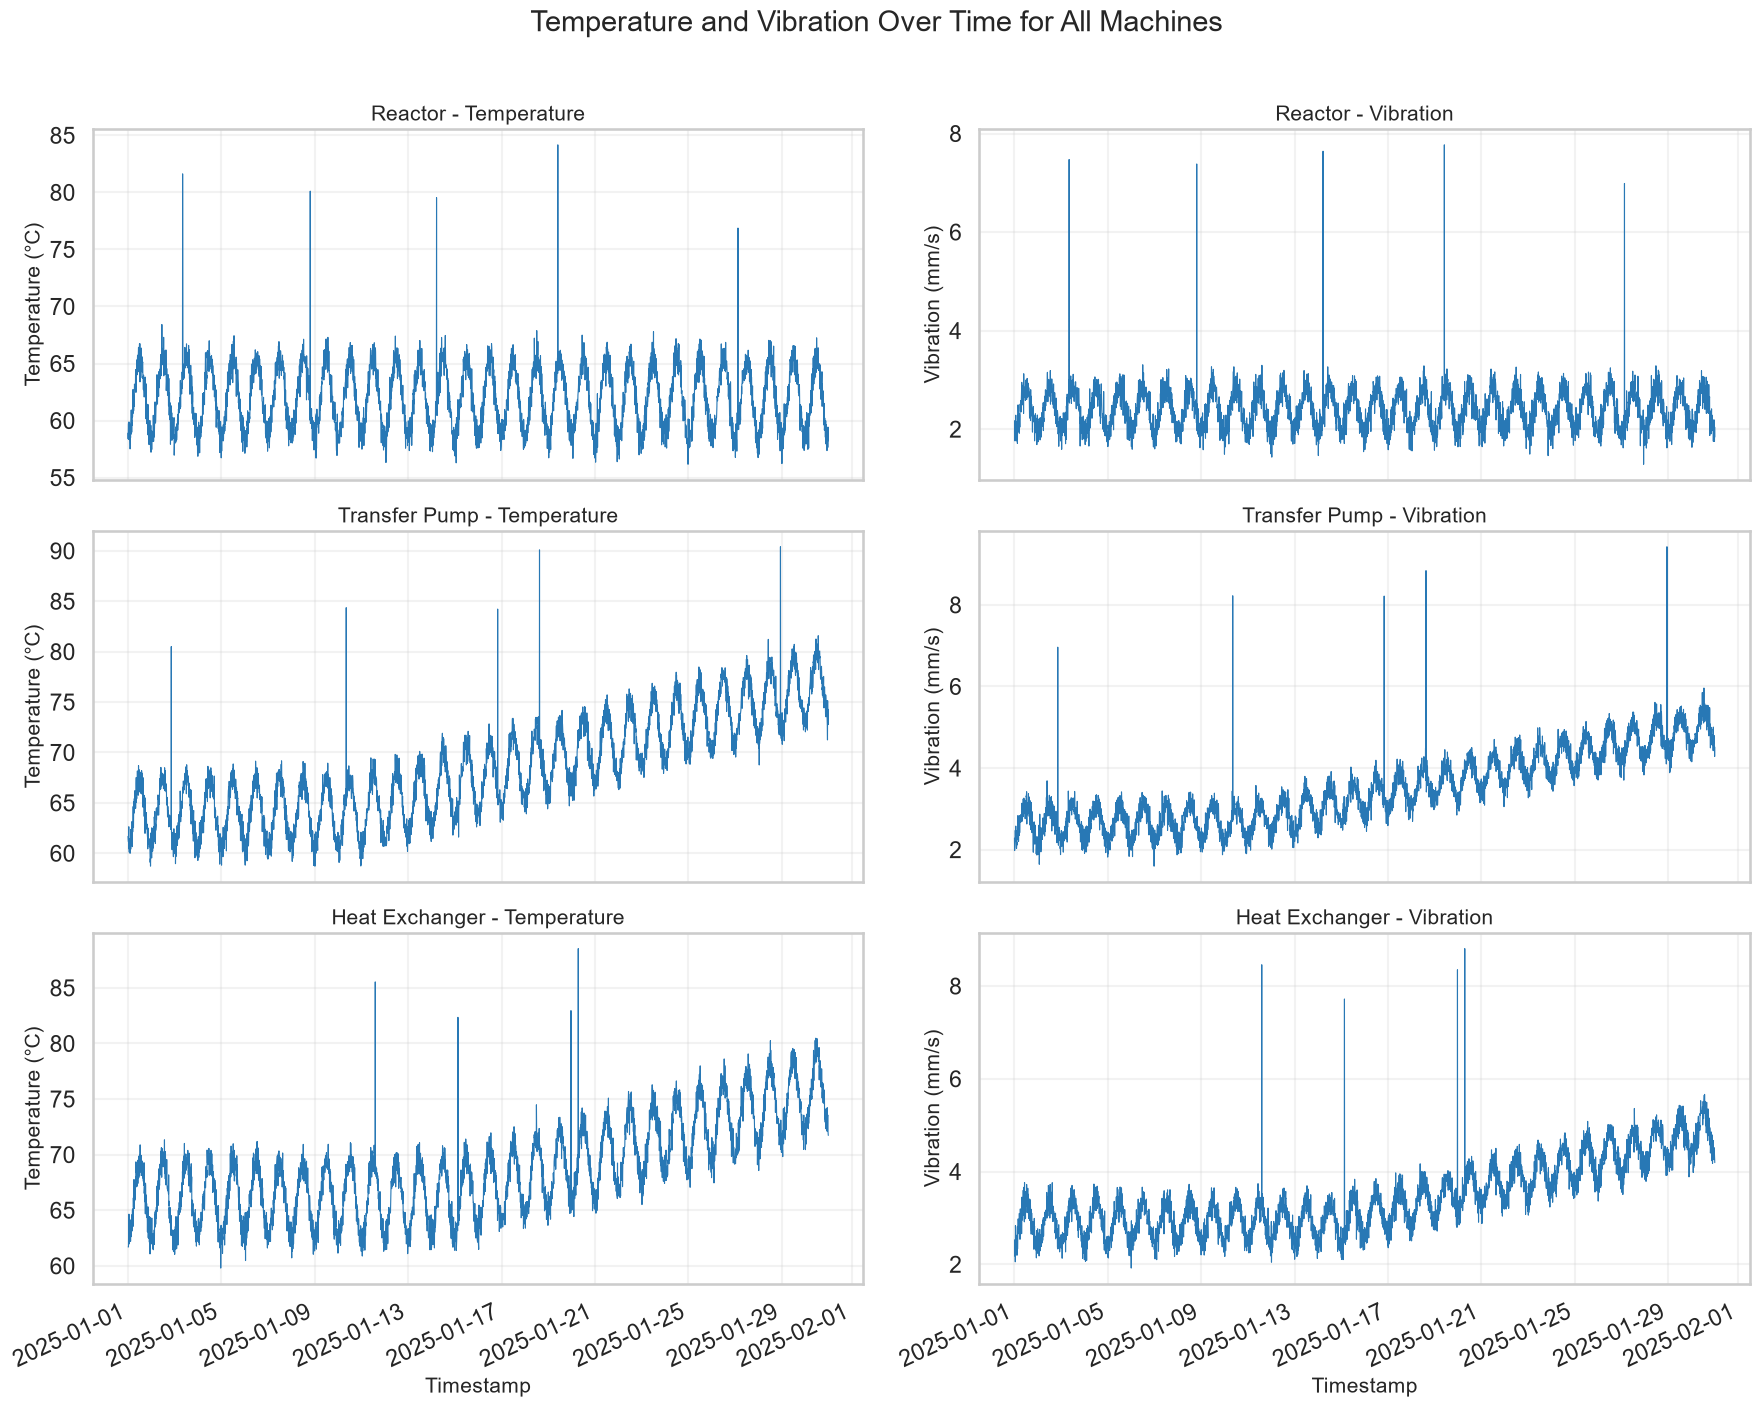

In [331]:
# Plot temperature and vibration over time for all three machines.
fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=True)
sensor_names = ["temperature", "vibration"]

# Give each machine one row and each sensor one column.
for row_number, machine_name in enumerate(machine_names):
    machine_rows = clean_data[clean_data["machine_id"] == machine_name]
    for column_number, sensor_name in enumerate(sensor_names):
        ax = axes[row_number, column_number]
        ax.plot(machine_rows["timestamp"], machine_rows[sensor_name], color=BLUE, linewidth=0.8)
        ax.set_title(machine_name + " - " + sensor_name.title(), fontsize=15)
        ax.set_ylabel("Temperature (°C)" if sensor_name == "temperature" else "Vibration (mm/s)")
        ax.grid(alpha=0.25)

# Label the shared time axis and save the combined chart.
axes[2, 0].set_xlabel("Timestamp")
axes[2, 1].set_xlabel("Timestamp")
fig.suptitle("Temperature and Vibration Over Time for All Machines", fontsize=21, y=1.01)
fig.autofmt_xdate(rotation=25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "15_all_machines_sensor_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Time-series interpretation:** The Reactor stays comparatively stable, while both the Transfer Pump and Heat Exchanger trend upward in temperature and vibration later in the sample. Seeing both sensors move on the same two machines makes those streams useful candidates for baseline monitoring; in this deliberately constructed dataset, the pattern is simulated rather than evidence of a real process change.

The traces retain short-term variation around the broader movement. An isolated peak should therefore be distinguished from a rising level that continues across many readings; the later rolling-window analysis formalizes that distinction.

Temperature and vibration both rise on the Transfer Pump and Heat Exchanger in the generated series. Their co-movement is part of the simulation; it does not show that one sensor causes the other to change.

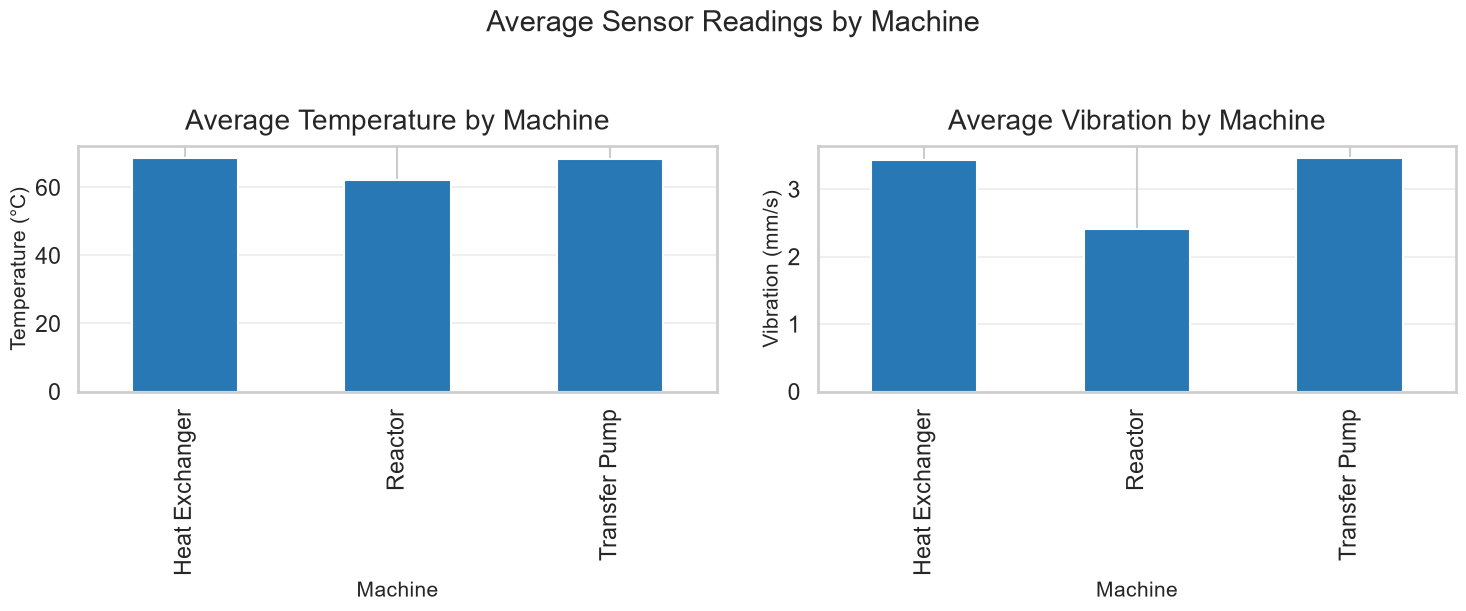

In [332]:
# Compare average temperature and vibration across all three machines.
average_sensors = clean_data.groupby("machine_id")[["temperature", "vibration"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Draw one simple bar chart for each sensor.
average_sensors["temperature"].plot(kind="bar", color=BLUE, ax=axes[0])
axes[0].set_title("Average Temperature by Machine", pad=12)
axes[0].set_xlabel("Machine")
axes[0].set_ylabel("Temperature (°C)")
axes[0].grid(axis="y", alpha=0.3)
average_sensors["vibration"].plot(kind="bar", color=BLUE, ax=axes[1])
axes[1].set_title("Average Vibration by Machine", pad=12)
axes[1].set_xlabel("Machine")
axes[1].set_ylabel("Vibration (mm/s)")
axes[1].grid(axis="y", alpha=0.3)

# Save both average comparisons together as one slide-ready image.
fig.suptitle("Average Sensor Readings by Machine", fontsize=21, y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "16_average_sensors_by_machine.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Machine comparison:** The full-period means are close for the Transfer Pump and Heat Exchanger (68.37 vs. 68.65 °C; 3.46 vs. 3.44 mm/s), while the Reactor is lower on both measures (62.03 °C; 2.40 mm/s). Aggregation hides when readings changed, and these means include simulated drift, so they are context rather than standalone alert limits.

The time-series plots add information that the averages cannot: the two rising machines have temporal changes in both sensors, whereas the Reactor does not show the same sustained pattern. This is why comparisons and baselines should be machine-specific rather than based on one pooled sensor level.

The heatmap displays pairwise correlations for temperature, vibration, hour, and one-hot machine indicators. These coefficients describe association in this simulated sample only; they do not establish a causal relationship or identify a physical mechanism.

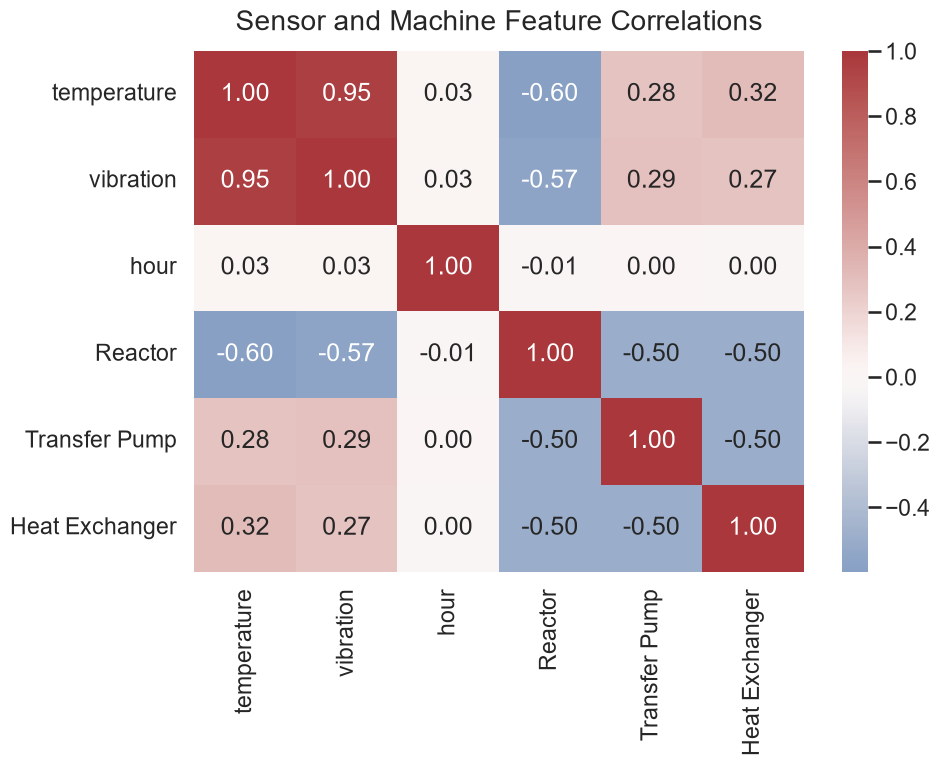

In [333]:
# Build a correlation heatmap with machine indicator features and hour.
correlation_data = clean_data[["temperature", "vibration"]].copy()
correlation_data["hour"] = clean_data["timestamp"].dt.hour
correlation_data["Reactor"] = (clean_data["machine_id"] == "Reactor").astype(int)
correlation_data["Transfer Pump"] = (clean_data["machine_id"] == "Transfer Pump").astype(int)
correlation_data["Heat Exchanger"] = (clean_data["machine_id"] == "Heat Exchanger").astype(int)
correlation_matrix = correlation_data.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Sensor and Machine Feature Correlations", pad=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**EDA takeaway:** Machine identity and time context matter: pooled averages can hide different sensor levels and later changes. The temperature–vibration relationship is descriptive, not causal, and the patterns remain hypotheses to investigate when working with real telemetry.

## 5. Methodology: Sliding-window anomaly detection

An extreme individual reading can be an isolated spike, while a sequence of shifted readings may signal a sustained change. A sliding window smooths short-term variation by summarizing recent observations, then moves forward one reading at a time so persistent movement can be compared with a historical reference. Here, six hours corresponds to 36 ten-minute readings.

In [353]:
# Calculate six-hour rolling means and standard deviations per machine.
WINDOW_READINGS = 6 * 6
rolling_data = clean_data.sort_values(["machine_id", "timestamp"]).copy()
for machine_name in machine_names:
    machine_mask = rolling_data["machine_id"] == machine_name
    for sensor_name in ["temperature", "vibration"]:
        sensor_values = rolling_data.loc[machine_mask, sensor_name]
        rolling_data.loc[machine_mask, sensor_name + "_rolling_mean"] = sensor_values.rolling(
            WINDOW_READINGS, min_periods=WINDOW_READINGS
        ).mean()
        rolling_data.loc[machine_mask, sensor_name + "_rolling_std"] = sensor_values.rolling(
            WINDOW_READINGS, min_periods=WINDOW_READINGS
        ).std()

# Set alert thresholds for the dashboard and sensor alerts.
warning_thresholds = {"temperature": 82.0, "vibration": 6.0}
critical_thresholds = {"temperature": 88.0, "vibration": 8.5}
print("Rolling window:", WINDOW_READINGS, "readings = 6 hours")
print("Warning thresholds:", warning_thresholds)
print("Critical thresholds:", critical_thresholds)

Rolling window: 36 readings = 6 hours
Warning thresholds: {'temperature': 82.0, 'vibration': 6.0}
Critical thresholds: {'temperature': 88.0, 'vibration': 8.5}


In [354]:
# Calculate baseline limits and flag drift and unusually large spikes.
baseline_end = rolling_data["timestamp"].min() + pd.Timedelta(days=3)
baseline_limits = {}

# Create separate flags for each sensor's drift and spikes.
for sensor_name in ["temperature", "vibration"]:
    rolling_data[sensor_name + "_drift"] = False
    rolling_data[sensor_name + "_spike"] = False
    rolling_data[sensor_name + "_spike_threshold"] = np.nan

# Compare each machine and sensor with its baseline and previous window.
for machine_name in machine_names:
    machine_mask = rolling_data["machine_id"] == machine_name
    baseline_mask = machine_mask & (rolling_data["timestamp"] < baseline_end)
    for sensor_name in ["temperature", "vibration"]:
        baseline_mean = rolling_data.loc[baseline_mask, sensor_name].mean()
        baseline_std = rolling_data.loc[baseline_mask, sensor_name].std()
        lower_limit = baseline_mean - 3 * baseline_std
        upper_limit = baseline_mean + 3 * baseline_std
        rolling_mean_name = sensor_name + "_rolling_mean"
        baseline_limits[(machine_name, sensor_name)] = (lower_limit, upper_limit)
        drift_mask = rolling_data["timestamp"] >= baseline_end
        drift_mask = machine_mask & drift_mask & (
            (rolling_data[rolling_mean_name] < lower_limit)
            | (rolling_data[rolling_mean_name] > upper_limit)
        )
        rolling_data.loc[drift_mask, sensor_name + "_drift"] = True

        machine_values = rolling_data.loc[machine_mask, sensor_name]
        z_score = (machine_values - baseline_mean) / baseline_std
        machine_drift = rolling_data.loc[machine_mask, sensor_name + "_drift"]
        spike_flags = (z_score > 3) & (~machine_drift)
        rolling_data.loc[machine_mask, sensor_name + "_spike"] = spike_flags
        rolling_data.loc[machine_mask, sensor_name + "_spike_threshold"] = baseline_mean + 3 * baseline_std

print("Baseline period ends:", baseline_end)
print("Sensor drift and spike flags are ready.")

Baseline period ends: 2025-01-04 00:00:00
Sensor drift and spike flags are ready.


For each machine and sensor, the first three days form the baseline, ending at 4 January 2025. Drift is flagged when a later six-hour rolling mean falls outside that machine's baseline mean ± 3 standard deviations. A spike is a raw reading more than 3 baseline standard deviations above the baseline mean, provided that reading is not already marked as drift. Thus drift is a rolling-mean departure and spikes are one-sided high-value flags; neither rule diagnoses failure. Warning and critical labels use separate fixed sensor thresholds (temperature 82/88 °C; vibration 6/8.5 mm/s). The report builder labels every flagged reading at least Warning, even below the warning threshold; only a reading at or above the critical threshold receives a Critical label. Warning totals therefore are not counts of absolute-threshold crossings.

In [349]:
# Create a two-panel raw-versus-rolling chart for one machine.
def plot_machine_drift(machine_name, output_name):
    machine_rows = rolling_data[rolling_data["machine_id"] == machine_name]
    baseline_start = machine_rows["timestamp"].min()
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Draw raw readings, rolling means, baseline period, limits, and drift points.
    for sensor_number, sensor_name in enumerate(["temperature", "vibration"]):
        ax = axes[sensor_number]
        limits = baseline_limits[(machine_name, sensor_name)]
        rolling_mean_name = sensor_name + "_rolling_mean"
        drift_name = sensor_name + "_drift"
        ax.axvspan(baseline_start, baseline_end, color="#9ecae1", alpha=0.25, label="First 3 days: baseline")
        ax.axhspan(limits[0], limits[1], color="#fdd835", alpha=0.18, label="Baseline ±3 SD limit")
        ax.plot(machine_rows["timestamp"], machine_rows[sensor_name], color=BLUE, alpha=0.55, linewidth=0.8, label="Raw")
        ax.plot(machine_rows["timestamp"], machine_rows[rolling_mean_name], color=RED, linewidth=2, label="6-hour rolling mean")
        drift_rows = machine_rows[machine_rows[drift_name]]
        ax.scatter(drift_rows["timestamp"], drift_rows[rolling_mean_name], color=RED, s=14, label="Detected drift", zorder=3)
        ax.set_title(machine_name + " - " + sensor_name.title(), fontsize=15)
        ax.set_xlabel("Timestamp")
        if sensor_name == "temperature":
            ax.set_ylabel("Temperature (°C)")
        else:
            ax.set_ylabel("Vibration (mm/s)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

    # Save the machine's comparison chart.
    fig.suptitle(machine_name + ": Baseline, Drift, and Rolling Means", fontsize=19)
    fig.autofmt_xdate(rotation=20)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

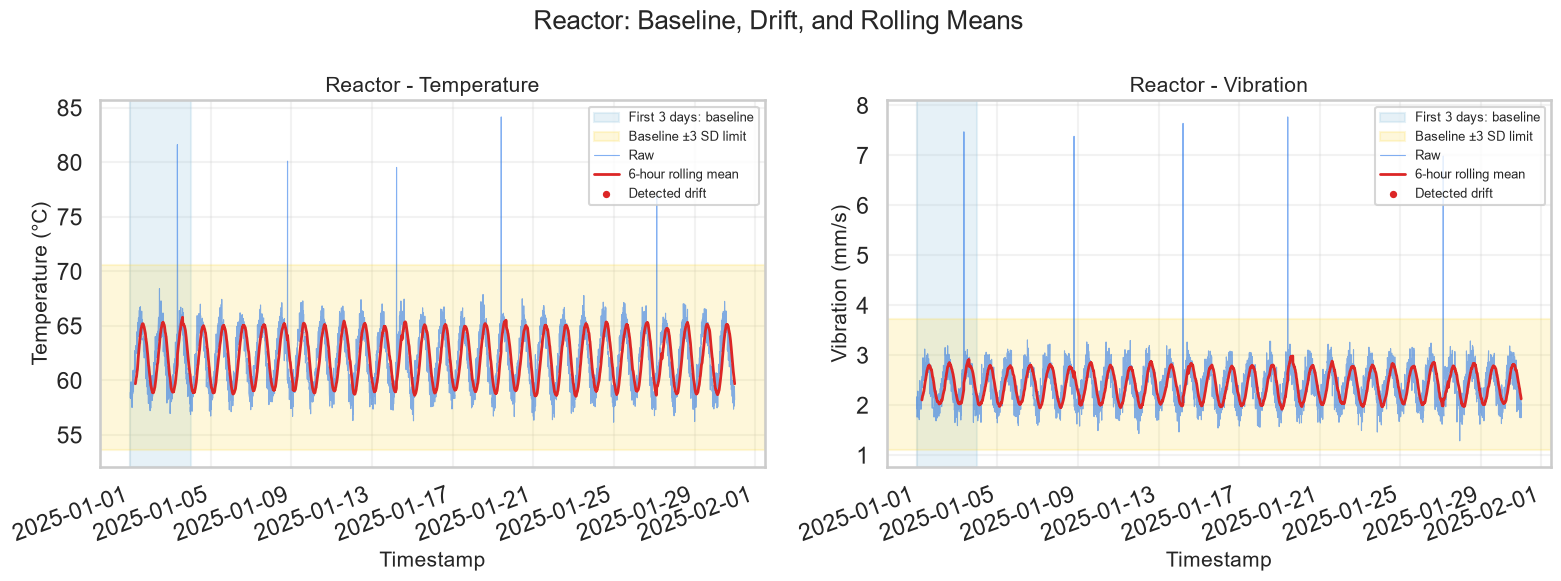

In [350]:
# Plot baseline, limits, raw readings, rolling means, and drift for the Reactor.
plot_machine_drift("Reactor", "17_reactor_baseline_drift.png")

**Reactor:** Neither rolling mean crosses its baseline band, so the method detects no sustained drift for this machine. Its later statistical flags, if any, are isolated high readings rather than rolling-mean drift.

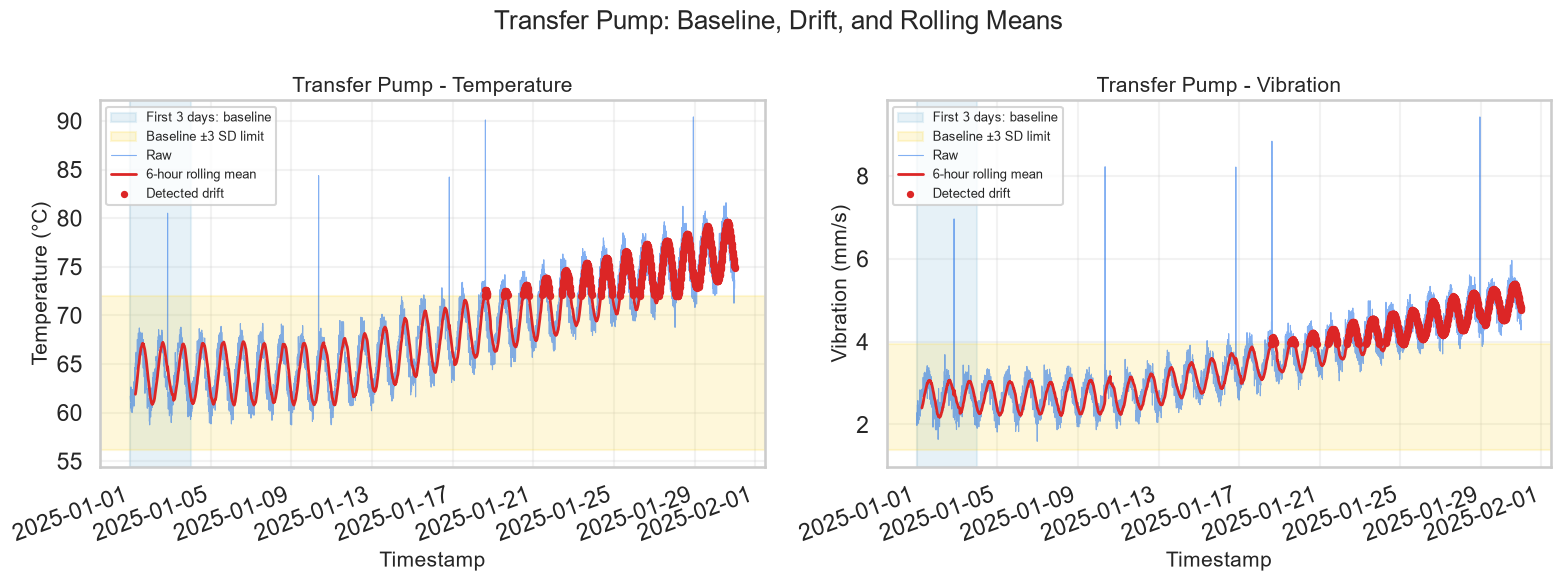

In [351]:
# Plot baseline, limits, raw readings, rolling means, and drift for the Transfer Pump.
plot_machine_drift("Transfer Pump", "18_transfer_pump_baseline_drift.png")

**Transfer Pump:** Both rolling means move above their machine-specific baseline limits. The raw series remains variable, but the smoother rolling means show a persistent upward departure more clearly than individual peaks.

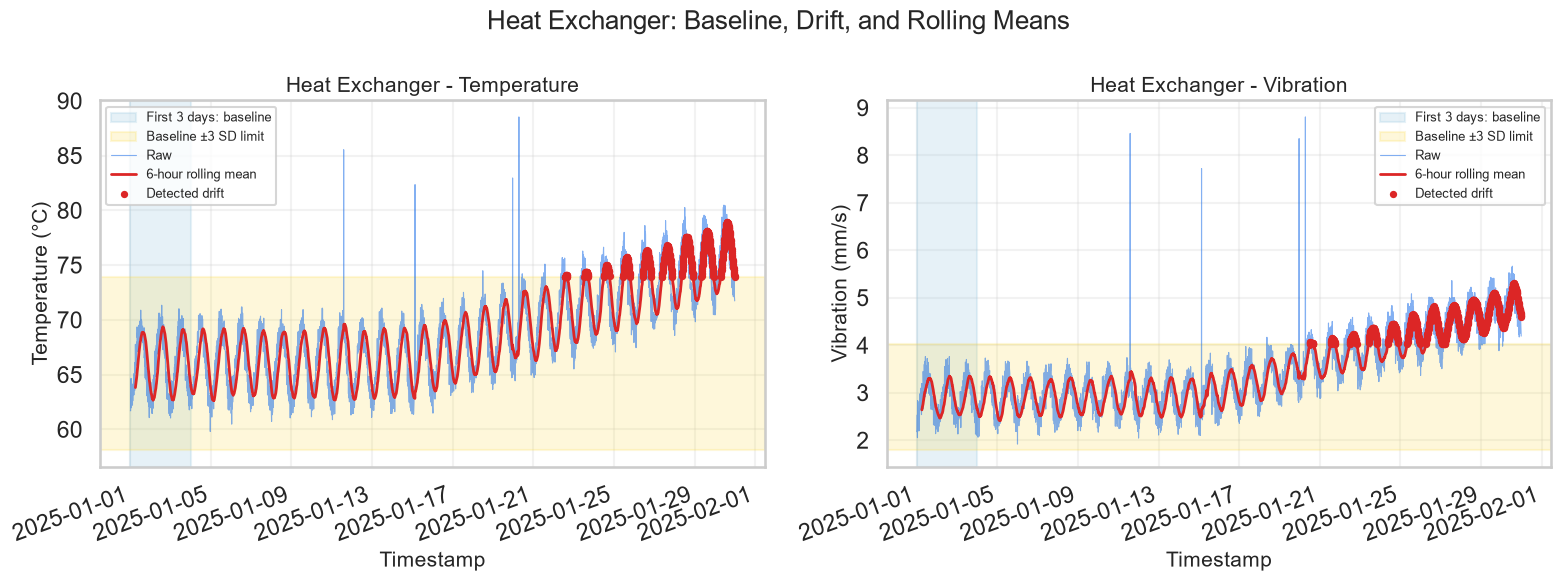

In [352]:
# Plot baseline, limits, raw readings, rolling means, and drift for the Heat Exchanger.
plot_machine_drift("Heat Exchanger", "19_heat_exchanger_baseline_drift.png")

**Heat Exchanger:** Temperature and vibration rolling means also rise beyond their baseline bands. The later crossings differ by sensor, so the first flagged time is a detector result—not necessarily the time the underlying change began.

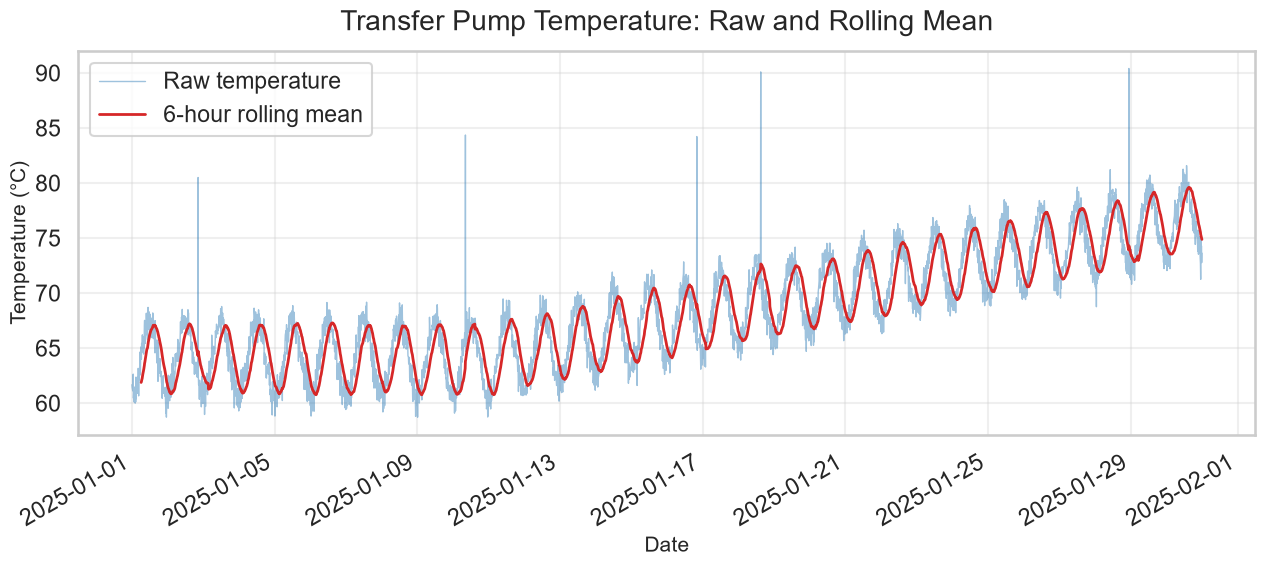

In [336]:
# Compare raw temperature with its six-hour rolling mean for the Transfer Pump.
transfer_pump_data = rolling_data[rolling_data["machine_id"] == "Transfer Pump"]
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(transfer_pump_data["timestamp"], transfer_pump_data["temperature"], color=BLUE, alpha=0.45, linewidth=1, label="Raw temperature")
ax.plot(transfer_pump_data["timestamp"], transfer_pump_data["temperature_rolling_mean"], color=RED, linewidth=2, label="6-hour rolling mean")
ax.set_title("Transfer Pump Temperature: Raw and Rolling Mean", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_transfer_pump_rolling_temperature.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Raw versus rolling:** The raw Transfer Pump temperature varies sharply from reading to reading; its six-hour rolling mean dampens those short-lived excursions and makes the broader rise easier to assess. Smoothing clarifies persistence but can delay the first detected crossing.

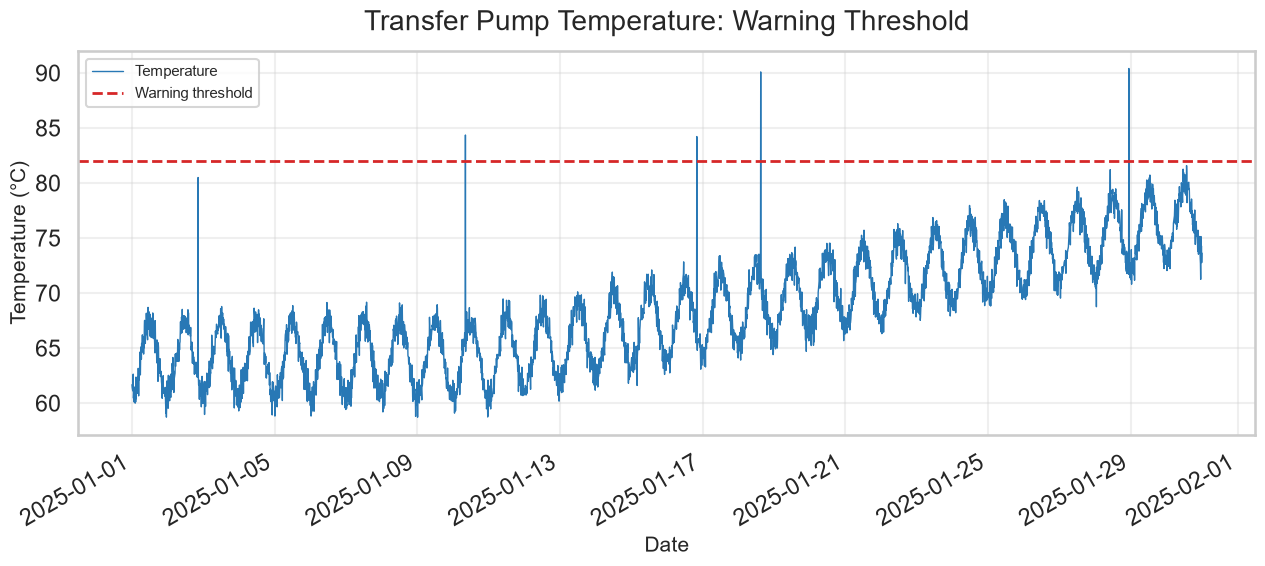

In [337]:
# Show the Transfer Pump temperature with its warning threshold.
temperature_limits = baseline_limits[("Transfer Pump", "temperature")]
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(transfer_pump_data["timestamp"], transfer_pump_data["temperature"], color=BLUE, linewidth=1, label="Temperature")
ax.axhline(warning_thresholds["temperature"], color=RED, linestyle="--", linewidth=2, label="Warning threshold")
ax.set_title("Transfer Pump Temperature: Warning Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_temperature_warning_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

This plot compares Transfer Pump raw temperature with the fixed 82 °C warning threshold. That absolute reference is distinct from the machine-specific baseline band used to flag drift; crossing either has a different meaning in the implemented rules.

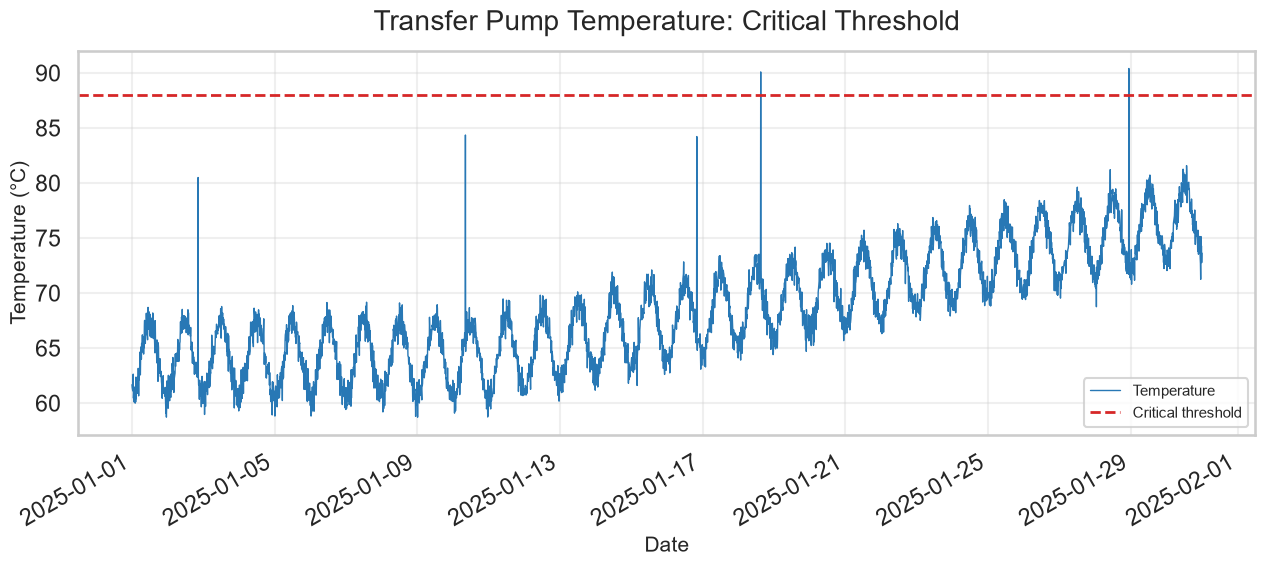

In [338]:
# Show the Transfer Pump temperature with its critical threshold.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(transfer_pump_data["timestamp"], transfer_pump_data["temperature"], color=BLUE, linewidth=1, label="Temperature")
ax.axhline(critical_thresholds["temperature"], color=RED, linestyle="--", linewidth=2, label="Critical threshold")
ax.set_title("Transfer Pump Temperature: Critical Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_temperature_critical_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

The 88 °C temperature line is the fixed critical threshold used for severity labels. It does not define the rolling-baseline drift rule, and a statistical drift flag alone does not imply that this threshold—or a failure condition—has been reached.

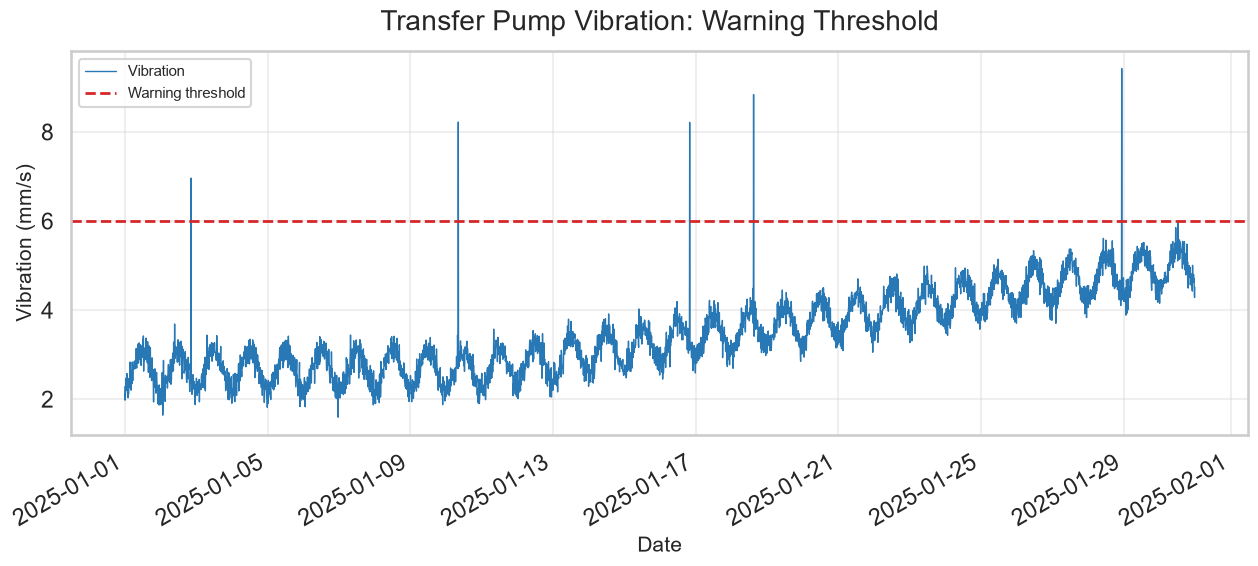

In [339]:
# Show the Transfer Pump vibration with its warning threshold.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(transfer_pump_data["timestamp"], transfer_pump_data["vibration"], color=BLUE, linewidth=1, label="Vibration")
ax.axhline(warning_thresholds["vibration"], color=RED, linestyle="--", linewidth=2, label="Warning threshold")
ax.set_title("Transfer Pump Vibration: Warning Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Vibration (mm/s)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_vibration_warning_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

The 6 mm/s vibration line is a fixed warning reference for the Transfer Pump. Individual excursions are visually distinct from the rolling-mean baseline comparison; the chart should be read as a screening view, not a diagnosis.

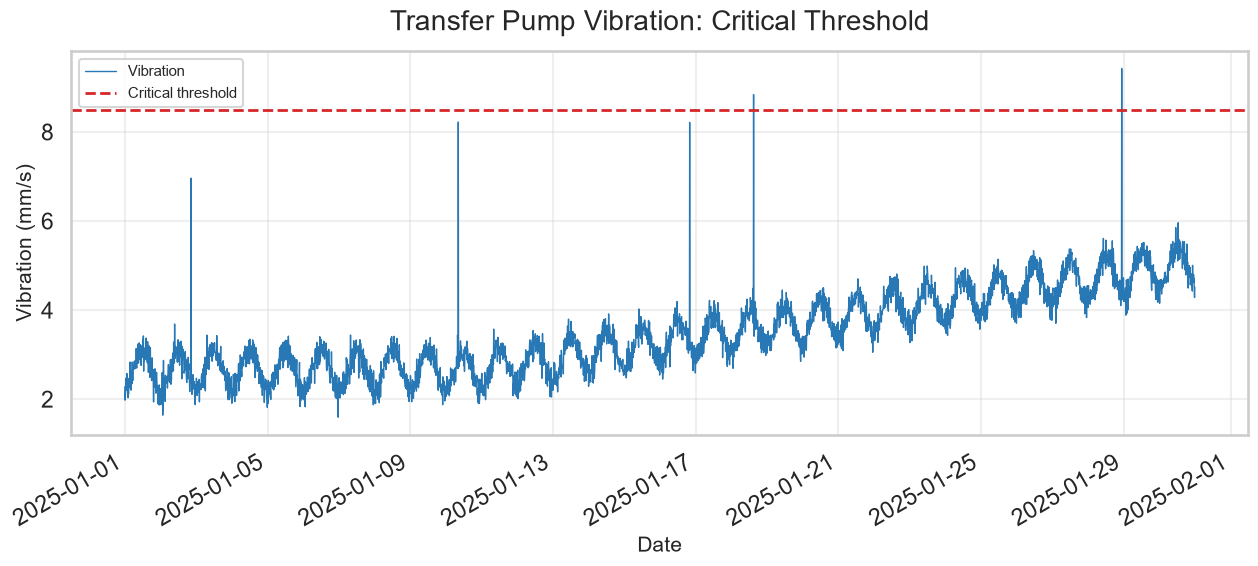

In [340]:
# Show the Transfer Pump vibration with its critical threshold.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(transfer_pump_data["timestamp"], transfer_pump_data["vibration"], color=BLUE, linewidth=1, label="Vibration")
ax.axhline(critical_thresholds["vibration"], color=RED, linestyle="--", linewidth=2, label="Critical threshold")
ax.set_title("Transfer Pump Vibration: Critical Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Vibration (mm/s)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "12_vibration_critical_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

The 8.5 mm/s line marks the configured critical vibration threshold for severity classification. It is a project rule, not a validated safe/unsafe boundary for real equipment.

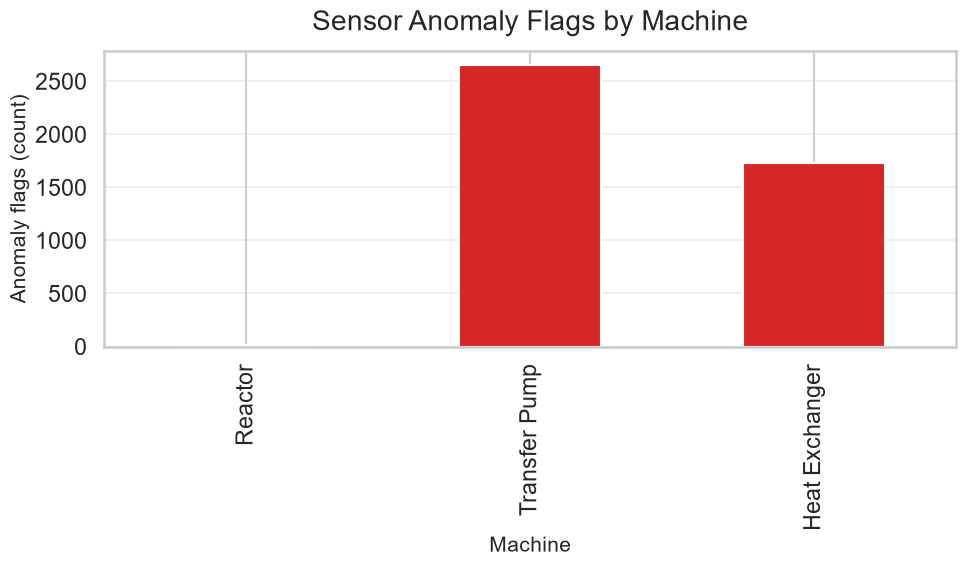

In [341]:
# Count sensor anomaly flags by machine for the first overview chart.
anomaly_counts = []
for machine_name in machine_names:
    machine_rows = rolling_data[rolling_data["machine_id"] == machine_name]
    count = int(machine_rows[["temperature_drift", "temperature_spike", "vibration_drift", "vibration_spike"]].sum().sum())
    anomaly_counts.append(count)
anomaly_by_machine = pd.Series(anomaly_counts, index=machine_names)
fig, ax = plt.subplots(figsize=(10, 6))
anomaly_by_machine.plot(kind="bar", color=RED, ax=ax)
ax.set_title("Sensor Anomaly Flags by Machine", pad=15)
ax.set_xlabel("Machine")
ax.set_ylabel("Anomaly flags (count)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "13_anomalies_by_machine.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Machine-level flags:** Flags are concentrated on the Transfer Pump and Heat Exchanger, consistent with their two-sensor rolling-mean departures; the Reactor contributes only a small number of isolated flags. Counts include flagged sensor readings, not independent failure events.

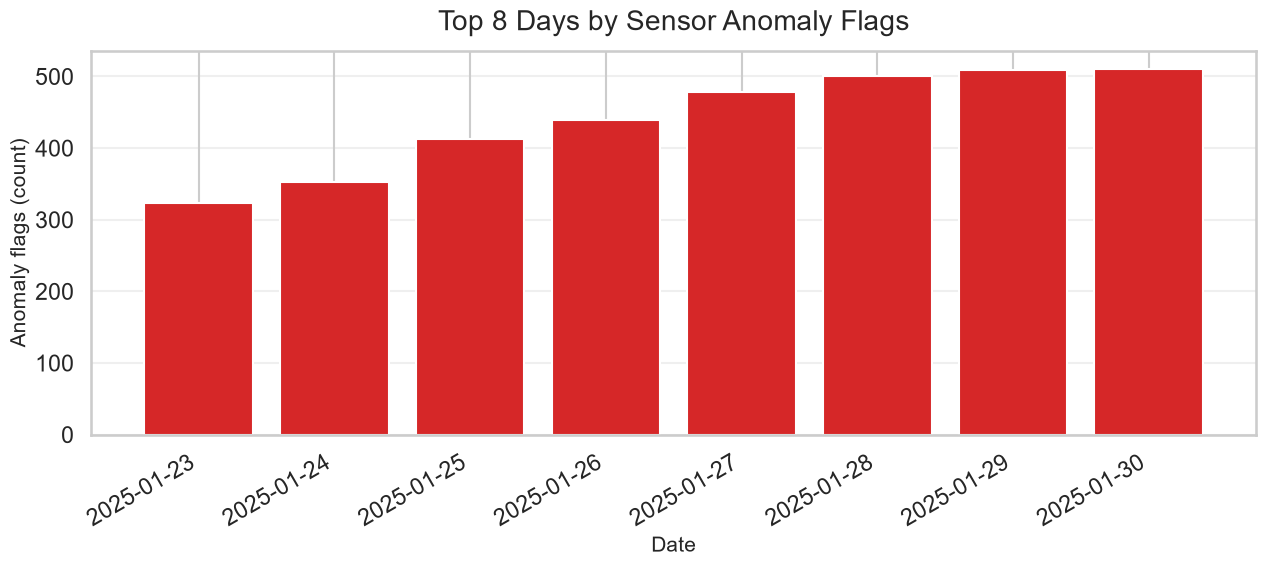

In [342]:
# Count flagged sensor readings by day.
rolling_data["day"] = rolling_data["timestamp"].dt.floor("D")
flag_columns = ["temperature_drift", "temperature_spike", "vibration_drift", "vibration_spike"]
daily_anomaly_counts = rolling_data.groupby("day")[flag_columns].sum().sum(axis=1)
top_anomaly_days = daily_anomaly_counts.nlargest(8).sort_index()
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(top_anomaly_days.index, top_anomaly_days.values, color=RED, width=0.8)
ax.set_title("Top 8 Days by Sensor Anomaly Flags", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Anomaly flags (count)")
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "14_anomalies_by_day.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

The chart selects the eight days with the most flagged readings. A sustained drift can contribute many flags on successive timestamps, so a high bar may reflect a continuing departure rather than many separate incidents. These counts show when the detector is active, not how many failures occurred.

In [343]:
# Find the first detected drift time for each machine and sensor.
drift_start_rows = []
for machine_name in machine_names:
    machine_rows = rolling_data[rolling_data["machine_id"] == machine_name]
    for sensor_name in ["temperature", "vibration"]:
        drift_rows = machine_rows[machine_rows[sensor_name + "_drift"]]
        if len(drift_rows) > 0:
            start_time = drift_rows["timestamp"].min()
        else:
            start_time = pd.NaT
        drift_start_rows.append({
            "machine_id": machine_name,
            "sensor": sensor_name,
            "first_drift_time": start_time
        })
drift_start_table = pd.DataFrame(drift_start_rows)
display(drift_start_table)
detected_drift = drift_start_table.dropna(subset=["first_drift_time"])
if len(detected_drift) > 0:
    print("Detected drift starts:")
    display(detected_drift)
else:
    print("No drift was detected with the selected baseline and window.")

,machine_id,sensor,first_drift_time
0,Reactor,temperature,NaT
1,Reactor,vibration,NaT
2,Transfer Pump,temperature,2025-01-18 14:30:00
3,Transfer Pump,vibration,2025-01-18 14:10:00
4,Heat Exchanger,temperature,2025-01-22 14:00:00
5,Heat Exchanger,vibration,2025-01-20 12:00:00


Detected drift starts:


,machine_id,sensor,first_drift_time
2,Transfer Pump,temperature,2025-01-18 14:30:00
3,Transfer Pump,vibration,2025-01-18 14:10:00
4,Heat Exchanger,temperature,2025-01-22 14:00:00
5,Heat Exchanger,vibration,2025-01-20 12:00:00


## 6. Drift timing and alert report

The first detected drift crossings are 18 January 2025 at 14:10 for Transfer Pump vibration and 14:30 for its temperature; for the Heat Exchanger they are 20 January at 12:00 for vibration and 22 January at 14:00 for temperature. The Reactor has no detected drift. These are first threshold-crossing timestamps from the selected baseline/window, not estimates of when a real equipment change began.

The exported report has one row per flagged sensor reading, with its value, threshold, severity label, and spike/drift type. Because a sustained drift is recorded at successive timestamps, report rows are not unique operational incidents. Severity is a rule-based category from the fixed thresholds, not a probability of failure.

In [344]:
# Convert sensor drift and spike flags into report rows.
report_rows = []
for row_number, row in rolling_data.iterrows():
    for sensor_name in ["temperature", "vibration"]:
        for anomaly_type in ["Drift", "Spike"]:
            flag_name = sensor_name + "_" + anomaly_type.lower()
            if row[flag_name]:
                value = float(row[sensor_name])
                warning_limit = warning_thresholds[sensor_name]
                critical_limit = critical_thresholds[sensor_name]
                if value >= critical_limit:
                    severity = "Critical"
                    threshold = critical_limit
                elif value >= warning_limit:
                    severity = "Warning"
                    threshold = warning_limit
                else:
                    severity = "Warning"
                    threshold = warning_limit
                if anomaly_type == "Drift":
                    limits = baseline_limits[(row["machine_id"], sensor_name)]
                    if value > limits[1]:
                        threshold = limits[1]
                    else:
                        threshold = limits[0]
                else:
                    threshold = row[sensor_name + "_spike_threshold"]
                report_rows.append({
                    "timestamp": row["timestamp"],
                    "machine_id": row["machine_id"],
                    "sensor": sensor_name,
                    "value": value,
                    "threshold": float(threshold),
                    "severity": severity,
                    "anomaly_type": anomaly_type
                })

# Create, sort, preview, and export the anomaly report.
report_columns = ["timestamp", "machine_id", "sensor", "value", "threshold", "severity", "anomaly_type"]
anomaly_report = pd.DataFrame(report_rows, columns=report_columns)
anomaly_report = anomaly_report.sort_values("timestamp").reset_index(drop=True)
display(anomaly_report.head(10))
anomaly_report.to_csv(OUTPUT_DIR / "anomaly_report.csv", index=False)
print("Report rows:", len(anomaly_report))
print("Saved to outputs/anomaly_report.csv")

,timestamp,machine_id,sensor,value,threshold,severity,anomaly_type
0,2025-01-02 20:30:00,Transfer Pump,temperature,80.504375,71.964468,Warning,Spike
1,2025-01-02 20:30:00,Transfer Pump,vibration,6.963192,3.942196,Warning,Spike
2,2025-01-03 08:10:00,Reactor,temperature,81.623440,70.611913,Warning,Spike
3,2025-01-03 08:10:00,Reactor,vibration,7.472401,3.727357,Warning,Spike
4,2025-01-03 08:20:00,Reactor,temperature,72.651563,70.611913,Warning,Spike
5,2025-01-08 19:20:00,Reactor,temperature,80.109675,70.611913,Warning,Spike
6,2025-01-08 19:20:00,Reactor,vibration,7.382111,3.727357,Warning,Spike
7,2025-01-10 08:20:00,Transfer Pump,temperature,84.364830,71.964468,Warning,Spike
8,2025-01-10 08:20:00,Transfer Pump,vibration,8.223507,3.942196,Warning,Spike
9,2025-01-11 14:10:00,Heat Exchanger,temperature,85.537693,73.868640,Warning,Spike


Report rows: 4394
Saved to outputs/anomaly_report.csv


In [345]:
# Summarize anomaly counts by machine and severity and save the table.
if len(anomaly_report) > 0:
    report_summary = anomaly_report.groupby(["machine_id", "severity"]).size().unstack(fill_value=0).reset_index()
else:
    report_summary = pd.DataFrame(columns=["machine_id", "Warning", "Critical"])
display(report_summary)
report_summary.to_csv(OUTPUT_DIR / "anomaly_summary_by_machine_severity.csv", index=False)

severity,machine_id,Critical,Warning
0,Heat Exchanger,2,1729
1,Reactor,0,11
2,Transfer Pump,4,2648


## 7. Results and operational interpretation

The report contains 4,394 alert rows: 2,652 for the Transfer Pump (2,648 Warning and 4 Critical), 1,731 for the Heat Exchanger (1,729 Warning and 2 Critical), and 11 Warning rows for the Reactor. The two drifting machines account for nearly all rows; the Reactor's flags are spikes, not detected drift. These totals count sensor readings, so repeated drift flags inflate the row count relative to distinct events.

The strongest signal in this simulated sample is the paired, persistent departure in both sensors on the Transfer Pump and Heat Exchanger. It warrants checking the data and the detection rules in a real deployment, but it is not evidence that either machine is failing. The few critical labels reflect configured thresholds applied to synthetic readings; statistical flags and severity labels are prompts for investigation, not proof of equipment damage.

## 8. Dashboard

The local Tkinter dashboard turns the saved readings and report into a review interface: KPI cards summarize alert totals, severity, and affected hours; equipment cards show latest readings and threshold-based status; selecting a machine updates temperature and vibration traces with fixed threshold lines and alert markers; and the alert feed lists recent flagged rows. It also exports the report. This is a desktop view of the notebook's simulated data, not a live equipment connection. The dashboard status/plot limits (temperature 90/95 °C; vibration 4.5/5.0 mm/s) differ from the alert-report thresholds and baseline-drift rule, so its status badges should not be interpreted as the same classification. Run the Tkinter cell in a local desktop session; its event loop remains active until the window is closed, and it is not suitable for Google Colab.

In [355]:
# ===== sensor MONITOR Dashboard =====
import os
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.dates as mdates

# Needs from earlier cells:
#   df_clean : timestamp, machine_id, temperature, vibration
#   report   : timestamp, machine_id, sensor, value, threshold, severity, anomaly_type
# Ensure the required datasets exist from earlier notebook cells.
if "df_clean" not in globals():
    if "rolling_data" in globals():
        df_clean = rolling_data[["timestamp", "machine_id", "temperature", "vibration"]].copy()
    elif "raw_data" in globals():
        df_clean = raw_data[["timestamp", "machine_id", "temperature", "vibration"]].copy()
    else:
        raise NameError("df_clean is not defined. Run the cleaning/preprocessing cell first.")

if "report" not in globals():
    if "report_rows" in globals():
        report = pd.DataFrame(report_rows)
    else:
        raise NameError("report is not defined. Run the anomaly detection cell first.")

# Normalize timestamps and keep only valid rows
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")
report["timestamp"] = pd.to_datetime(report["timestamp"], errors="coerce")

df_clean = df_clean.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
report = report.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
report["timestamp"] = pd.to_datetime(report["timestamp"])

# ---------- Settings (edit these) ----------
# Friendly names shown on screen (use your own machine ids on the left)
MACHINE_NAMES = {
"Reactor": "Reactor",
"Transfer Pump": "Transfer Pump",
"Heat Exchanger": "Heat Exchanger",
}

# Same limits as Section 7
LIMITS = {
    "temperature": {"warning": 90, "critical": 95, "unit": "°C"},
    "vibration":   {"warning": 4.5, "critical": 5.0, "unit": "mm/s"},
}

# ---------- Colors ----------
BG = "#eef3f9"       # page background
CARD = "#ffffff"
BORDER = "#dbe3ee"
NAVY = "#0a1628"     # header
NAVY2 = "#0f2038"    # sub header
TEXT = "#0f172a"
MUTED = "#64748b"
BLUE = "#1d6fe8"
CYAN = "#38bdf8"
RED = "#dc2626"
AMBER = "#f59e0b"
GREEN = "#16a34a"

# status -> (main color, soft background color)
STATUS_STYLE = {
    "CRITICAL": (RED, "#fee2e2"),
    "WARNING": (AMBER, "#fef3c7"),
    "NORMAL": (GREEN, "#dcfce7"),
}

machines = list(df_clean["machine_id"].unique())


# ---------- Small helper functions ----------
def display_name(machine):
    # Friendly name if we have one, otherwise the original id
    return MACHINE_NAMES.get(machine, machine)


def get_status(temp, vib):
    # Decide the status from the latest reading
    if temp >= LIMITS["temperature"]["critical"] or vib >= LIMITS["vibration"]["critical"]:
        return "CRITICAL"
    if temp >= LIMITS["temperature"]["warning"] or vib >= LIMITS["vibration"]["warning"]:
        return "WARNING"
    return "NORMAL"


def make_kpi(parent, title, color, column):
    # One KPI card with a title and a big number
    parent.columnconfigure(column, weight=1, uniform="kpi")
    card = tk.Frame(parent, bg=CARD, highlightbackground=BORDER,
                    highlightthickness=1, padx=16, pady=12)
    card.grid(row=0, column=column, sticky="nsew", padx=6)
    tk.Label(card, text=title, font=("Segoe UI", 8, "bold"), bg=CARD, fg=MUTED).pack(anchor="w")
    value = tk.Label(card, text="0", font=("Segoe UI", 24, "bold"), bg=CARD, fg=color)
    value.pack(anchor="w")
    return value


def section_title(parent, left_text, right_text=""):
    # Section heading with optional small text on the right
    row = tk.Frame(parent, bg=BG)
    row.pack(fill="x", pady=(18, 6))
    tk.Label(row, text=left_text, font=("Segoe UI", 11, "bold"), bg=BG, fg=TEXT).pack(side="left")
    right = tk.Label(row, text=right_text, font=("Segoe UI", 8, "bold"), bg=BG, fg=BLUE)
    right.pack(side="right")
    return right


def make_click(machine):
    # Returns a function that selects this machine when its card is clicked
    def on_click(event):
        selected_var.set(machine)
        update_all()
    return on_click


equip_widgets = {}


def build_equipment_card(parent, machine, column):
    # One equipment card: dot, name, status badge, latest temp and vibration
    parent.columnconfigure(column, weight=1, uniform="equip")
    card = tk.Frame(parent, bg=CARD, highlightbackground=BORDER,
                    highlightthickness=1, padx=16, pady=12, cursor="hand2")
    card.grid(row=0, column=column, sticky="nsew", padx=6)

    top = tk.Frame(card, bg=CARD)
    top.pack(fill="x")
    dot = tk.Label(top, text="●", font=("Segoe UI", 14), bg=CARD)
    dot.pack(side="left")
    name = tk.Label(top, text=display_name(machine).upper(),
                    font=("Segoe UI", 10, "bold"), bg=CARD, fg=TEXT)
    name.pack(side="left", padx=8)
    badge = tk.Label(top, text="", font=("Segoe UI", 8, "bold"), padx=8, pady=2)
    badge.pack(side="right")

    bottom = tk.Frame(card, bg=CARD)
    bottom.pack(fill="x", pady=(10, 0))
    temp = tk.Label(bottom, text="", font=("Segoe UI", 9), bg=CARD, fg=MUTED)
    temp.pack(side="left")
    vib = tk.Label(bottom, text="", font=("Segoe UI", 9), bg=CARD, fg=MUTED)
    vib.pack(side="right")

    # Clicking anywhere on the card selects the machine
    for widget in [card, top, dot, name, badge, bottom, temp, vib]:
        widget.bind("<Button-1>", make_click(machine))

    equip_widgets[machine] = {"card": card, "dot": dot, "badge": badge, "temp": temp, "vib": vib}


def draw_panel(ax, data, alerts, sensor, title, show_dates):
    # Draws one telemetry chart (line + limit lines + red anomaly dots)
    limits = LIMITS[sensor]
    ax.clear()
    ax.plot(data["timestamp"], data[sensor], color=BLUE, linewidth=1.2)
    ax.axhline(limits["critical"], color=RED, linestyle="--", linewidth=1.2)
    ax.axhline(limits["warning"], color=AMBER, linestyle=":", linewidth=1.2)

    points = alerts[alerts["sensor"] == sensor]
    ax.scatter(points["timestamp"], points["value"], color=RED, s=14, zorder=5)

    ax.set_title(title, loc="left", fontsize=9, fontweight="bold")
    ax.set_ylabel(limits["unit"], fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
    if show_dates:
        for label in ax.get_xticklabels():
            label.set_rotation(30)
    else:
        ax.tick_params(labelbottom=False)


def update_all():
    # Refreshes everything on the screen

    # --- KPI cards (all machines) ---
    kpi_total.config(text=str(len(report)))
    kpi_critical.config(text=str((report["severity"] == "Critical").sum()))
    kpi_warning.config(text=str((report["severity"] == "Warning").sum()))
    kpi_hours.config(text=str(report["timestamp"].dt.floor("h").nunique()))

    # --- Equipment cards ---
    any_critical = False
    any_warning = False
    for machine in machines:
        last = df_clean[df_clean["machine_id"] == machine].sort_values("timestamp").iloc[-1]
        level = get_status(last["temperature"], last["vibration"])
        color, soft = STATUS_STYLE[level]
        if level == "CRITICAL":
            any_critical = True
        if level == "WARNING":
            any_warning = True

        w = equip_widgets[machine]
        w["dot"].config(fg=color)
        w["badge"].config(text=level, fg=color, bg=soft)
        w["temp"].config(text=f"TEMP  {last['temperature']:.1f} °C")
        w["vib"].config(text=f"VIB  {last['vibration']:.2f} mm/s")
        if machine == selected_var.get():
            w["card"].config(highlightbackground=BLUE, highlightthickness=2)
        else:
            w["card"].config(highlightbackground=BORDER, highlightthickness=1)

    # --- Header status ---
    if any_critical:
        header_dot.config(fg=RED)
        header_text.config(text="ATTENTION REQUIRED")
    elif any_warning:
        header_dot.config(fg=AMBER)
        header_text.config(text="WARNINGS ACTIVE")
    else:
        header_dot.config(fg=GREEN)
        header_text.config(text="SYSTEM OPERATIONAL")

    # --- Telemetry charts (last 48 hours of the selected machine) ---
    machine = selected_var.get()
    selected_label.config(text=f"{display_name(machine).upper()}  /  SELECTED")

    data = df_clean[df_clean["machine_id"] == machine].sort_values("timestamp")
    start = data["timestamp"].max() - pd.Timedelta(hours=48)
    data = data[data["timestamp"] >= start]
    alerts = report[(report["machine_id"] == machine) & (report["timestamp"] >= start)]

    draw_panel(ax_temp, data, alerts, "temperature", "TEMPERATURE TELEMETRY", False)
    draw_panel(ax_vib, data, alerts, "vibration", "VIBRATION TELEMETRY", True)
    fig.tight_layout(h_pad=2.5)
    chart_canvas.draw()

    # --- Alert feed (latest 15 alerts, all machines) ---
    for row in table.get_children():
        table.delete(row)
    latest = report.sort_values("timestamp", ascending=False).head(15)
    for i, r in latest.iterrows():
        sensor = r["sensor"]
        unit = LIMITS[sensor]["unit"]
        message = f"{r['anomaly_type']} detected: {sensor} {r['value']:.1f} {unit} (limit {r['threshold']:.1f})"
        tag = "crit" if r["severity"] == "Critical" else "warn"
        table.insert("", "end", tags=(tag,), values=(
            r["timestamp"].strftime("%d %b %H:%M"),
            display_name(r["machine_id"]),
            sensor.capitalize(),
            message,
            r["severity"].upper(),
        ))


def export_report():
    # Saves the anomaly report as CSV
    os.makedirs("outputs", exist_ok=True)
    report.to_csv("outputs/anomaly_report.csv", index=False)
    messagebox.showinfo("Export done", "Saved to outputs/anomaly_report.csv")


def on_content_resize(event):
    # Keeps the scroll area the same size as the content
    scroll_canvas.configure(scrollregion=scroll_canvas.bbox("all"))


def on_canvas_resize(event):
    # Makes the content as wide as the window
    scroll_canvas.itemconfig(content_id, width=event.width)


def on_mousewheel(event):
    # Scroll with the mouse wheel
    scroll_canvas.yview_scroll(int(-event.delta / 120), "units")


# ---------- Window ----------
root = tk.Tk()
root.title("Sensor Monitoring and Anomaly Detection Dashboard")
root.geometry("1280x820")
root.configure(bg=BG)
selected_var = tk.StringVar(value=machines[0])

# Table style
style = ttk.Style()
style.theme_use("clam")
style.configure("Treeview", background=CARD, fieldbackground=CARD, foreground=TEXT,
                rowheight=28, borderwidth=0, font=("Segoe UI", 9))
style.configure("Treeview.Heading", background=NAVY, foreground="white",
                font=("Segoe UI", 9, "bold"), padding=6)

# ---------- Header (stays fixed at the top) ----------
header = tk.Frame(root, bg=NAVY)
header.pack(fill="x")
title_box = tk.Frame(header, bg=NAVY)
title_box.pack(side="left", padx=24, pady=12)
tk.Label(title_box, text="Sensor Monitoring and Anomaly Detection Dashboard", font=("Segoe UI", 18, "bold"),
         bg=NAVY, fg="white").pack(anchor="w")
tk.Label(title_box, text="INDUSTRIAL SENSOR INTELLIGENCE", font=("Segoe UI", 8, "bold"),
         bg=NAVY, fg=CYAN).pack(anchor="w")

status_box = tk.Frame(header, bg=NAVY)
status_box.pack(side="right", padx=24)
header_dot = tk.Label(status_box, text="●", font=("Segoe UI", 14), bg=NAVY, fg=GREEN)
header_dot.pack(side="left")
header_text = tk.Label(status_box, text="", font=("Segoe UI", 9, "bold"), bg=NAVY, fg="white")
header_text.pack(side="left", padx=8)

subbar = tk.Frame(root, bg=NAVY2)
subbar.pack(fill="x")
tk.Label(subbar, text="MONITORING ALL EQUIPMENT", font=("Segoe UI", 8, "bold"),
         bg=NAVY2, fg="white").pack(side="left", padx=24, pady=10)
tk.Button(subbar, text="REFRESH", command=update_all, bg=BLUE, fg="white",
          font=("Segoe UI", 8, "bold"), relief="flat", padx=14, pady=4).pack(side="right", padx=(6, 24))
tk.Button(subbar, text="EXPORT REPORT", command=export_report, bg=NAVY2, fg="white",
          font=("Segoe UI", 8, "bold"), relief="solid", bd=1, padx=14, pady=4).pack(side="right")

# ---------- Scrollable area ----------
scroll_canvas = tk.Canvas(root, bg=BG, highlightthickness=0)
scrollbar = ttk.Scrollbar(root, orient="vertical", command=scroll_canvas.yview)
scroll_canvas.configure(yscrollcommand=scrollbar.set)
scrollbar.pack(side="right", fill="y")
scroll_canvas.pack(side="left", fill="both", expand=True)

content = tk.Frame(scroll_canvas, bg=BG)
content_id = scroll_canvas.create_window((0, 0), window=content, anchor="nw")
content.bind("<Configure>", on_content_resize)
scroll_canvas.bind("<Configure>", on_canvas_resize)
scroll_canvas.bind_all("<MouseWheel>", on_mousewheel)

page = tk.Frame(content, bg=BG)
page.pack(fill="both", expand=True, padx=20, pady=18)

# ---------- KPI cards ----------
kpi_row = tk.Frame(page, bg=BG)
kpi_row.pack(fill="x")
kpi_total = make_kpi(kpi_row, "TOTAL ALERTS", TEXT, 0)
kpi_critical = make_kpi(kpi_row, "CRITICAL", RED, 1)
kpi_warning = make_kpi(kpi_row, "WARNINGS", AMBER, 2)
kpi_hours = make_kpi(kpi_row, "ANOMALY HOURS", TEXT, 3)

# ---------- Equipment status ----------
section_title(page, "EQUIPMENT STATUS")
equip_row = tk.Frame(page, bg=BG)
equip_row.pack(fill="x")
for i, machine in enumerate(machines):
    build_equipment_card(equip_row, machine, i)

# ---------- Live sensor telemetry ----------
selected_label = section_title(page, "LIVE SENSOR TELEMETRY", "")
chart_frame = tk.Frame(page, bg=CARD, highlightbackground=TEXT, highlightthickness=1)
chart_frame.pack(fill="x")

fig = Figure(figsize=(10, 5), dpi=100, facecolor=CARD)
ax_temp = fig.add_subplot(211)
ax_vib = fig.add_subplot(212)
chart_canvas = FigureCanvasTkAgg(fig, master=chart_frame)
chart_canvas.get_tk_widget().pack(fill="both", expand=True)

# ---------- Alert feed ----------
section_title(page, "ALERT FEED", "RECENT OPERATIONAL EVENTS")
table = ttk.Treeview(page, columns=("Time", "Machine", "Sensor", "Message", "Status"),
                     show="headings", height=8)
widths = {"Time": 120, "Machine": 140, "Sensor": 110, "Message": 520, "Status": 100}
for name in widths:
    table.heading(name, text=name.upper() if name != "Message" else "OPERATIONAL MESSAGE")
    table.column(name, width=widths[name], anchor="center")
table.tag_configure("crit", foreground=RED)
table.tag_configure("warn", foreground="#b45309")
table.pack(fill="x", pady=(0, 20))

# ---------- Start ----------
update_all()
root.mainloop()

KeyboardInterrupt: 

## 9. Conclusions and recommendations

**Evidence from this investigation**
- The 30-day sample is synthetic and includes designed daily variation, spikes, missing fields, duplicates, and gradual changes on two machines.
- Cleaning reduced 13,089 raw rows to 12,196 usable unique machine-time records, with no remaining missing values or duplicate keys.
- Machine-specific six-hour rolling means identify temperature and vibration drift on the Transfer Pump and Heat Exchanger, but not on the Reactor.
- The 4,394 report rows are repeated statistical flags, not 4,394 independent incidents or confirmed failures.

**Practical next steps**
1. When applying this workflow to real telemetry, first verify sensor calibration, data continuity, and operating context around sustained crossings; do not infer failure from a flag alone.
2. Validate machine- and sensor-specific baselines and warning/critical limits with engineering and maintenance teams, then assess false alarms and detection delay on historical data.
3. Preserve the raw file, cleaning comparison, and alert report for traceability, and treat the dashboard as a review aid until it is connected to validated production data.

**Files in `outputs/`**
The code below lists all files produced when the notebook cells have run.

In [348]:
# List every generated file in the outputs folder.
for output_file in sorted(OUTPUT_DIR.iterdir()):
    print(output_file.name)

01_missing_values.png
02_average_temperature_by_machine.png
03_average_vibration_by_machine.png
04_machine_b_daily_temperature.png
04_transfer_pump_daily_temperature.png
05_machine_b_daily_vibration.png
05_transfer_pump_daily_vibration.png
06_average_temperature_by_hour.png
07_correlation_heatmap.png
08_machine_b_rolling_temperature.png
08_transfer_pump_rolling_temperature.png
09_temperature_warning_threshold.png
10_temperature_critical_threshold.png
11_vibration_warning_threshold.png
12_vibration_critical_threshold.png
13_anomalies_by_machine.png
14_anomalies_by_day.png
15_all_machines_sensor_timeseries.png
16_average_sensors_by_machine.png
anomaly_report.csv
anomaly_summary_by_machine_severity.csv
data_quality_comparison.csv
machine_summary.csv
sensor_readings_raw.csv
